# Week 4 — Embeddings, Similarity & Modalities
### *Understanding How Meaning Becomes Geometry*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/week4_embeddings_similarity.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

---

### 🎯 Learning Objectives
By the end of this week, you should be able to:
- Explain what an **embedding** is and how it represents meaning numerically.
- Compute and interpret **cosine similarity** between vectors.
- Describe **how embeddings are learned** from data.
- Understand **semantic search** conceptually and mathematically.
- Visualize embedding clusters and **multimodal representations**.
- Identify where embeddings fit in the **Unifying System Diagram v3**.


In [1]:
# @title Setup (Run this first)
!git clone  --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import sys; sys.path.append('/content/main')
from course_utils import lab4_setup, show_mermaid
lab4_setup()
print("✅ Environment ready!")

🔧 Setting up your environment...
  → Installing core packages...
installing mermaid-python
  → Installing additional packages: scikit-learn
  → Setting random seed for reproducible results...
  → Checking API key...
🔑 Enter your OpenAI API key.
   (It will only be stored in this Colab runtime - it's safe!)
   Get your key from: https://platform.openai.com/api-keys
OpenAI API key: ··········
✅ API key set.
  → Adding course files to path...
✅ Setup complete!
✅ lab4_setup complete — ready.
✅ Environment ready!


# 🧭 Day 1 — Geometry of Meaning

Today, we’ll explore **how words become vectors**, how we **measure similarity** between them, and how **geometry encodes meaning**.


## 🌟 Motivating Example — “Cardiac Doctor” vs Keyword Search

Let’s see why **semantic search** is powerful. Keyword search fails on synonyms like *“cardiac doctor” → “cardiologist”*.


In [2]:
# @title Keyword vs Semantic Search Demo
from openai import OpenAI
import numpy as np
client = OpenAI()

query = "cardiac doctor"
docs = [
    "A cardiologist treats heart disease.",
    "This is about car engines.",
    "Nutrition and exercise matter.",
]

keyword_hits = [d for d in docs if any(w in d.lower() for w in query.split())]

def cosine(a,b): return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))

q_embed = client.embeddings.create(input=query, model="text-embedding-3-small").data[0].embedding
doc_embeds = [client.embeddings.create(input=d, model="text-embedding-3-small").data[0].embedding for d in docs]
sims = [cosine(q_embed, e) for e in doc_embeds]
ranked = [x for _,x in sorted(zip(sims, docs), reverse=True)]

print("🔹 Keyword search:", keyword_hits)
print("🔸 Semantic search:", ranked[:2])


🔹 Keyword search: []
🔸 Semantic search: ['A cardiologist treats heart disease.', 'Nutrition and exercise matter.']


## 🧮 Measuring Similarity with Cosine Similarity

Embeddings are **vectors**. To measure how similar two meanings are, we compute the **cosine of the angle** between them:

$$ \text{similarity}(A,B) = \frac{A \cdot B}{\|A\|\|B\|}$$

If the angle is small, the meanings align closely.


In [3]:
# @title Simple Cosine Demo
import numpy as np
A, B = np.array([1, 1]), np.array([2, 2])
C = np.array([1, -1])

def cos(a,b): return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
print("A vs B:", cos(A,B))
print("A vs C:", cos(A,C))


A vs B: 0.9999999999999998
A vs C: 0.0


## 🎨 Visualizing Cosine Similarity
As the **angle** between vectors increases, cosine similarity drops from 1 → 0 → –1.


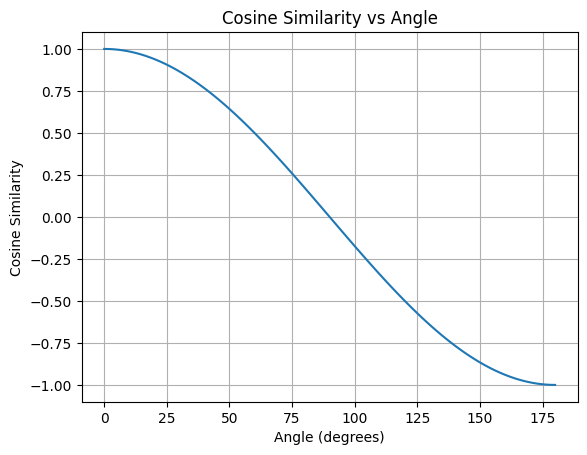

In [4]:
# @title Plot Cosine vs Angle
import matplotlib.pyplot as plt
import numpy as np
angles = np.linspace(0, np.pi, 100)
cos_vals = np.cos(angles)
plt.plot(np.degrees(angles), cos_vals)
plt.xlabel("Angle (degrees)")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity vs Angle")
plt.grid(True); plt.show()


## 🔥 Heatmap of Pairwise Cosine Similarities

Let’s visualize relationships among different text snippets in **embedding space**.


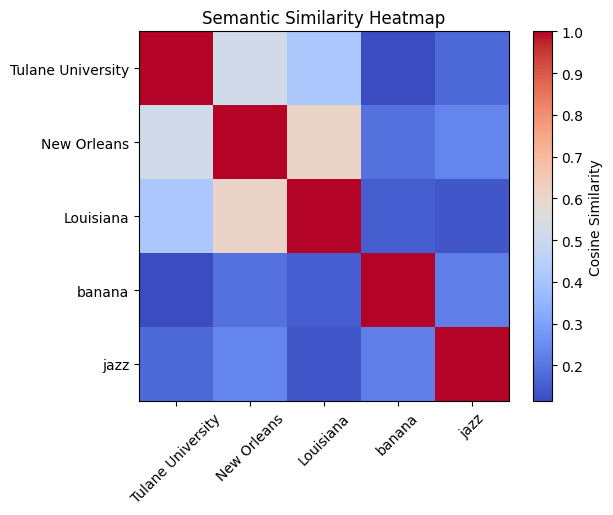

In [5]:
# @title Pairwise Cosine Heatmap
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

texts = ["Tulane University", "New Orleans", "Louisiana", "banana", "jazz"]
embs = [client.embeddings.create(input=t, model="text-embedding-3-small").data[0].embedding for t in texts]
cos_mat = cosine_similarity(embs)
plt.imshow(cos_mat, cmap="coolwarm"); plt.xticks(range(len(texts)), texts, rotation=45); plt.yticks(range(len(texts)), texts)
plt.colorbar(label="Cosine Similarity")
plt.title("Semantic Similarity Heatmap")
plt.show()


## 🧩 How Are Embeddings Learned?

Embeddings are learned by predicting **context words** from target words.  
This process (like in Word2Vec) moves related words closer together in vector space.


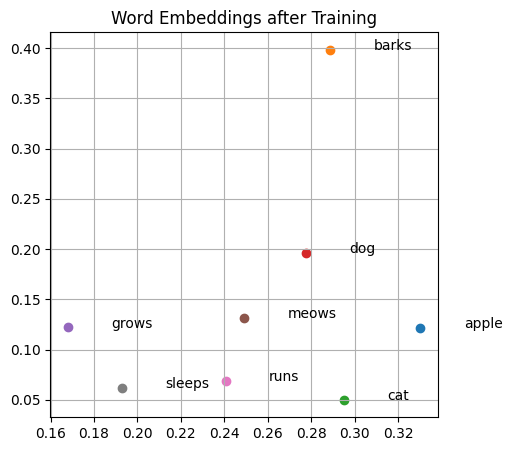

In [6]:
# @title Mini Skip-Gram Training Simulation
import numpy as np, matplotlib.pyplot as plt

sentences = [["dog","barks"],["cat","meows"],["apple","grows"],["dog","runs"],["cat","sleeps"]]
vocab = sorted({w for s in sentences for w in s})
word2idx = {w:i for i,w in enumerate(vocab)}
np.random.seed(0); embs = np.random.randn(len(vocab),2)*0.3

pairs = [(s[0],s[1]) for s in sentences]
lr=0.05; epochs=100

def cosine(a,b): return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
for _ in range(epochs):
  for c,ctx in pairs:
    i,j=word2idx[c],word2idx[ctx]; v,vc=embs[i],embs[j]
    sim=cosine(v,vc); grad=lr*(1-sim)*(vc-v); embs[i]+=grad; embs[j]-=grad

plt.figure(figsize=(5,5))
for w,v in zip(vocab,embs):
  plt.scatter(*v); plt.text(v[0]+.02,v[1],w)
plt.title("Word Embeddings after Training"); plt.grid(True); plt.show()


# 🚀 Day 2 — From Similarity to Semantic Systems

Today, we’ll use embeddings for **semantic search** and explore **multimodal embeddings** (text + images).

## 🔍 What Is Semantic Search?

| Type | How It Works | Example Behavior |
|------|---------------|------------------|
| Keyword search | Matches literal words | “cardiac doctor” ≠ “cardiologist” |
| Semantic search | Uses vector similarity | “cardiac doctor” ≈ “cardiologist” |

### 🧭 How Semantic Search Works

1. Embed the **query** and **documents** into vectors.  
2. Compute **cosine similarity** between query and each document.  
3. Sort by similarity → retrieve the top results.


## 📊 Visualizing the Embedding Store
Each document is a point; the query appears near semantically similar items.

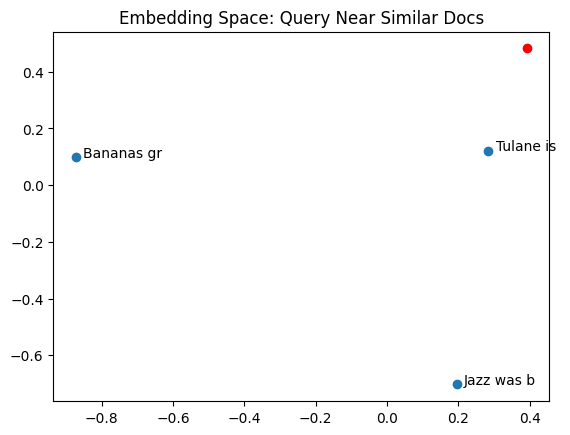

In [7]:
# @title PCA Visualization
from sklearn.decomposition import PCA
docs = ["Tulane is in Louisiana.","Jazz was born in New Orleans.","Bananas grow in tropical climates."]
query="Louisiana university"
doc_embs=[client.embeddings.create(input=d, model="text-embedding-3-small").data[0].embedding for d in docs]
q_emb=client.embeddings.create(input=query, model="text-embedding-3-small").data[0].embedding
pca=PCA(n_components=2); pts=pca.fit_transform(doc_embs+[q_emb])
import matplotlib.pyplot as plt
plt.scatter(pts[:-1,0],pts[:-1,1]);plt.scatter(pts[-1,0],pts[-1,1],c='red')
for i,d in enumerate(docs): plt.text(pts[i,0]+.02,pts[i,1],d[:10])
plt.title("Embedding Space: Query Near Similar Docs"); plt.show()


## 🖼️ Multimodal Embeddings with CLIP

CLIP embeds **text and images** into the same vector space, enabling cross-modal comparisons.

In [8]:
# @title CLIP Example
from openai import OpenAI; client=OpenAI()
text="a dog playing fetch in the park"
image_url="https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"
text_emb=client.embeddings.create(input=text,model="text-embedding-3-small").data[0].embedding
img_emb=client.embeddings.create(input=image_url,model="text-embedding-3-small").data[0].embedding
def cosine(a,b): return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
print("Cosine similarity (text vs image):", cosine(text_emb,img_emb))


Cosine similarity (text vs image): 0.16947030674712396


## 🧠 Concept Check

1. What does cosine similarity measure?  
2. Why does cosine similarity capture meaning better than Euclidean distance?  
3. How can embeddings unify text and images?

In [9]:
# @title ✅ Reveal Answers
answers={
 "1":"The angle between two vectors — smaller angle = more similar meaning.",
 "2":"Cosine focuses on direction (meaning) rather than magnitude (frequency).",
 "3":"By embedding both modalities into the same vector space (e.g., CLIP)."
}
for k,v in answers.items(): print(f"{k}. {v}")


1. The angle between two vectors — smaller angle = more similar meaning.
2. Cosine focuses on direction (meaning) rather than magnitude (frequency).
3. By embedding both modalities into the same vector space (e.g., CLIP).


<details>
<summary>📘 Instructor Notes</summary>

**Day 1**
- (10m) Review Lab 3 results.
- (10m) Motivating example: “cardiac doctor”.
- (20m) Cosine math + plots.
- (15m) Heatmap exploration.
- (15m) Skip-gram simulation.

**Day 2**
- (15m) Semantic search overview.
- (10m) PCA visualization.
- (20m) Multimodal CLIP demo.
- (10m) Cosine vs Euclidean.
- (10m) Wrap-up & concept check.

Reflection: “How might we measure whether embeddings are *good enough* for a task?”
</details>
